Block 1 Checkpoint - Anisotropic Oscillator

In [2]:
import numpy as np
import matplotlib.pyplot as plt

This code simulates the two dimensional anisotropic oscillator, in which the two perpendicular directions have uncoupled force equations and have different coefficients of restitution. I have also included dampening in the simulation. The simulation is verified through a combination of exact solution overlay, as well as energy tracking.

In [59]:
m = 1.0
g = 10.0
x_0 = 1.0
y_0 = 1.0
vx_0 = 0.0
vy_0 = 0.0

def Two_D_Aniso_Oscillator(kx, bx, ky, by, dt, runtime):

    x = x_0
    y = y_0
    vx = vx_0
    vy = vy_0
    t = 0.0
    E_total = 0.5*m*(vx**2 + vy**2) + 0.5*(kx*x**2+ky*y**2)

    state = {'t':[t], 'x':[x], 'y':[y], 'vx':[vx], 'vy':[vy], 'E':[E_total]}

    while t<=runtime:

        ax = - (kx/m) * x - (bx/m) * vx
        ay = - (ky/m) * y - (by/m) * vy

        vx += ax*dt
        x += vx*dt

        vy += ay*dt
        y += vy*dt

        t += dt
        E_total = 0.5*m*(vx**2 + vy**2) + 0.5*(kx*x**2+ky*y**2)

        state['t'].append(t)
        state['x'].append(x)
        state['y'].append(y)
        state['vx'].append(vx)
        state['vy'].append(vy)
        state['E'].append(E_total)

    return state

Here I have run the simulation in the zero dampening case and with several plots and have overlayed the exact solutions over relevant plots. We can see that for this case, the energy tracking confirms that energy is roughly conserved and the exact solution curve overlays show that the simulation is fairly accurate.

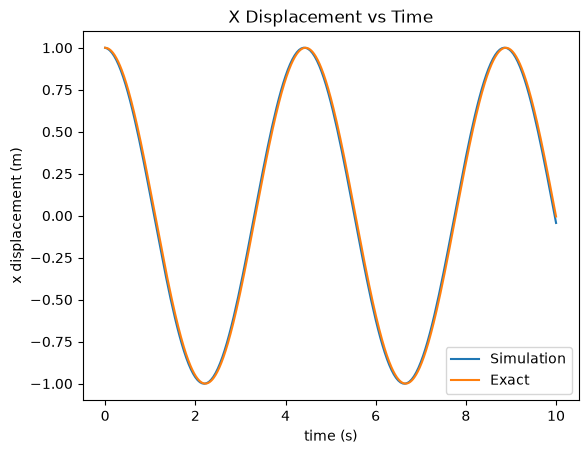

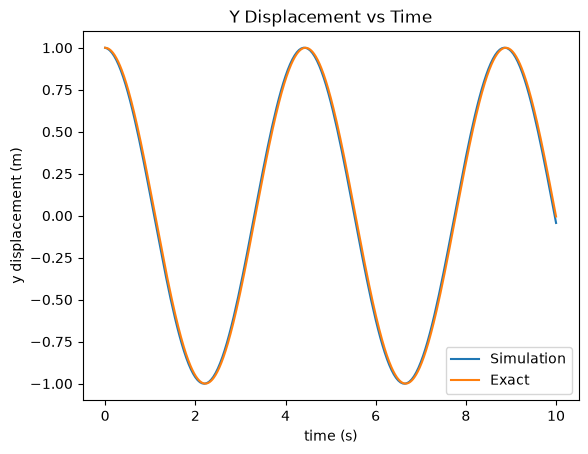

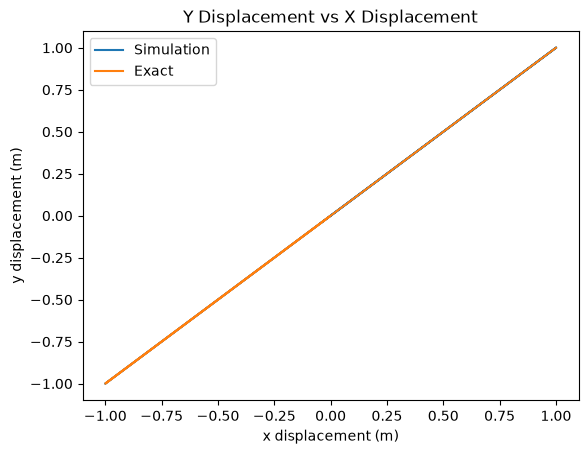

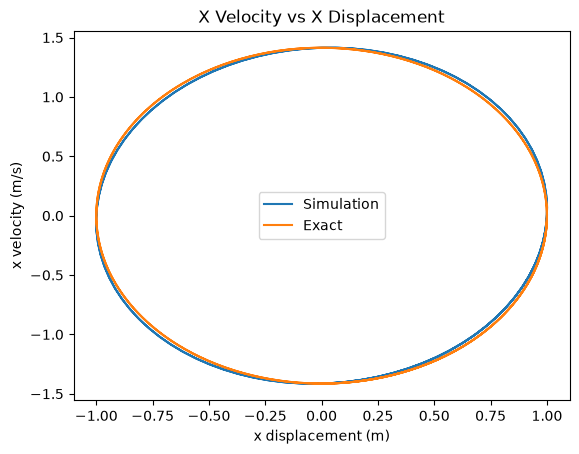

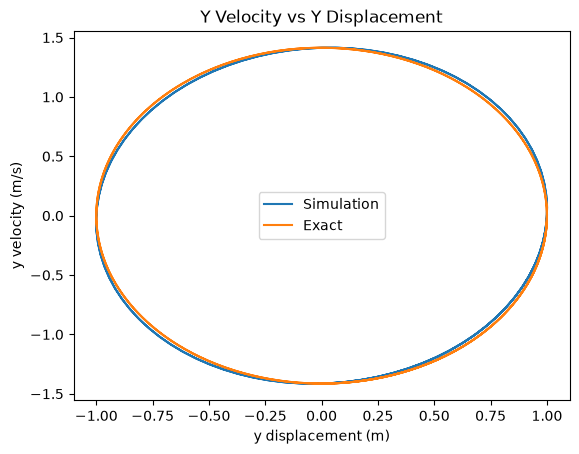

Text(0.5, 1.0, 'Energy vs Time')

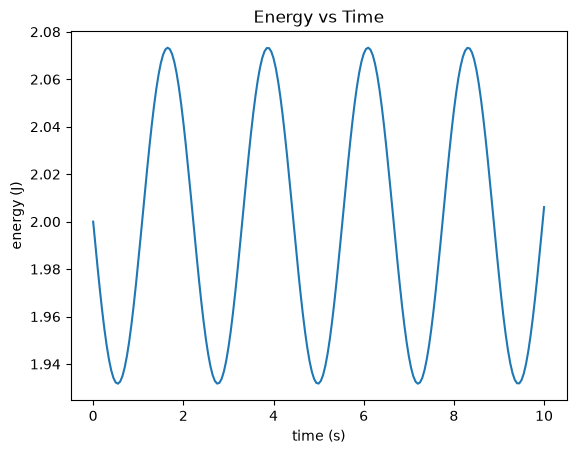

In [68]:
Kx, Ky = 2, 2
Bx, By = 0, 0
GammaX, GammaY = Bx/(2*m), By/(2*m)
Wx, Wy = np.sqrt(Kx/m), np.sqrt(Ky/m)
Wdx, Wdy = np.sqrt(Wx**2+GammaX**2), np.sqrt(Wy**2+GammaY**2)

def Aniso_Exact_x(t):
    A_x = x_0
    B_x = (vx_0+GammaX*x_0)/Wdx
    return np.exp(-GammaX*t)*(A_x*np.cos(Wdx*t)+B_x*np.sin(Wdx*t))

def Aniso_Exact_y(t):
    A_y = y_0
    B_y = (vy_0+GammaY*y_0)/Wdy
    return np.exp(-GammaY*t)*(A_y*np.cos(Wdy*t)+B_y*np.sin(Wdy*t))  

def Aniso_Exact_vx(t):
    return -(Wx**2*x_0)/(Wdx)*np.exp(-GammaX*t)*(np.sin(Wdx*t))

def Aniso_Exact_vy(t):
    return -(Wy**2*y_0)/(Wdy)*np.exp(-GammaY*t)*(np.sin(Wdy*t)) 

time = np.linspace(0,10,1000)
x_t = Aniso_Exact_x(time)
y_t = Aniso_Exact_y(time)
vx_t = Aniso_Exact_vx(time)
vy_t = Aniso_Exact_vy(time)

data_sim = Two_D_Aniso_Oscillator(Kx, Bx, Ky, By, 0.05, 10)

plt.plot(data_sim['t'], data_sim['x'], label='Simulation')
plt.plot(time, x_t, label='Exact')
plt.xlabel('time (s)')
plt.ylabel('x displacement (m)')
plt.title('X Displacement vs Time')
plt.legend()
plt.show()
plt.plot(data_sim['t'],data_sim['y'], label='Simulation')
plt.plot(time, y_t, label='Exact')
plt.xlabel('time (s)')
plt.ylabel('y displacement (m)')
plt.title('Y Displacement vs Time')
plt.legend()
plt.show()
plt.plot(data_sim['x'],data_sim['y'], label='Simulation')
plt.plot(x_t, y_t, label='Exact')
plt.xlabel('x displacement (m)')
plt.ylabel('y displacement (m)')
plt.title('Y Displacement vs X Displacement')
plt.legend()
plt.show()
plt.plot(data_sim['x'],data_sim['vx'], label='Simulation')
plt.plot(x_t, vx_t, label='Exact')
plt.xlabel('x displacement (m)')
plt.ylabel('x velocity (m/s)')
plt.title('X Velocity vs X Displacement')
plt.legend()
plt.show()
plt.plot(data_sim['y'],data_sim['vy'], label='Simulation')
plt.plot(y_t, vy_t, label='Exact')
plt.xlabel('y displacement (m)')
plt.ylabel('y velocity (m/s)')
plt.title('Y Velocity vs Y Displacement')
plt.legend()
plt.show()
plt.plot(data_sim['t'],data_sim['E'])
plt.xlabel('time (s)')
plt.ylabel('energy (J)')
plt.title('Energy vs Time')

Here I have run the simulation in the anisotropic dampening case and with several plots and have overlayed the exact solutions over relevant plots. We can see that for this case, the energy trackingshows that energy is lost as we would expect with dampening and the exact solution curve overlays show that the simulation is fairly accurate.

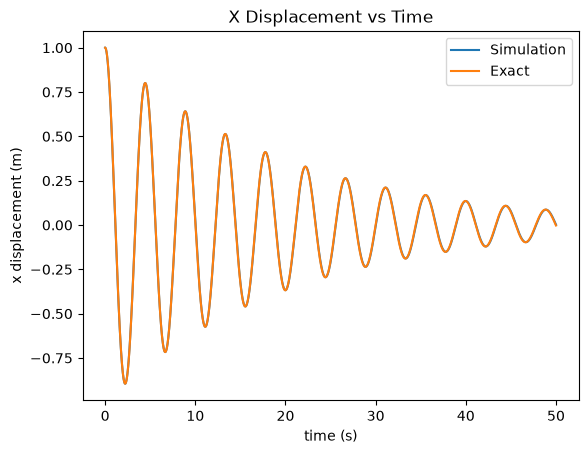

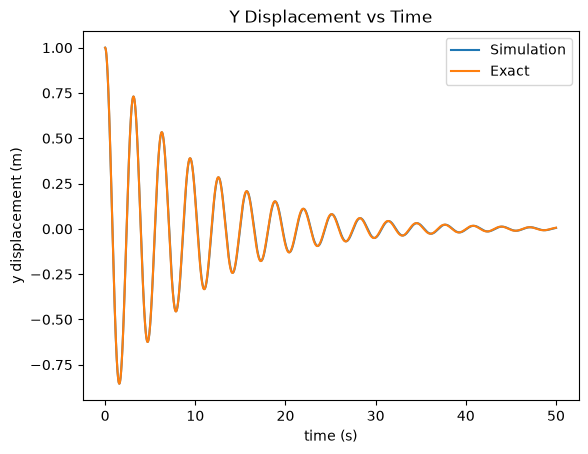

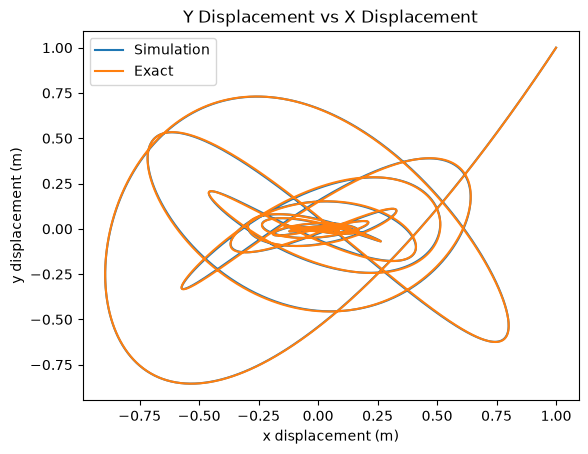

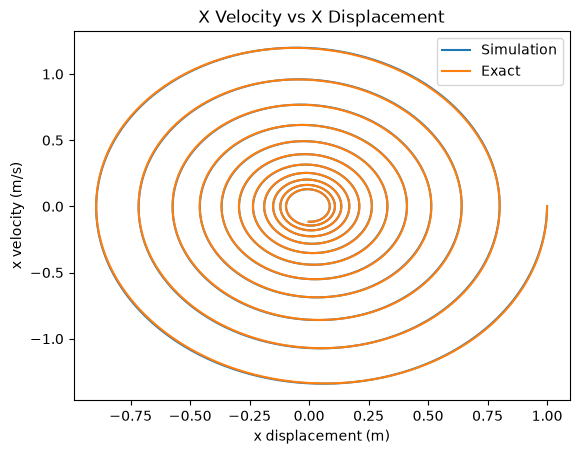

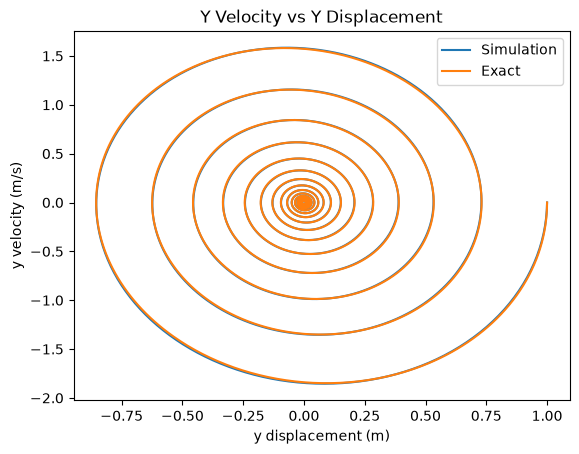

Text(0.5, 1.0, 'Energy vs Time')

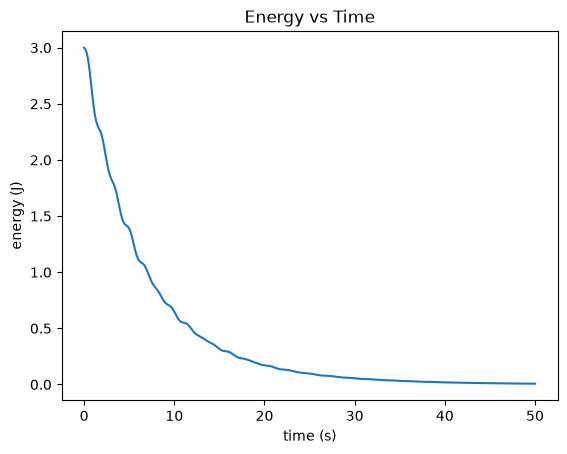

In [70]:
Kx, Ky = 2, 4
Bx, By = 0.1, 0.2
GammaX, GammaY = Bx/(2*m), By/(2*m)
Wx, Wy = np.sqrt(Kx/m), np.sqrt(Ky/m)
Wdx, Wdy = np.sqrt(Wx**2+GammaX**2), np.sqrt(Wy**2+GammaY**2)

def Aniso_Exact_x(t):
    A_x = x_0
    B_x = (vx_0+GammaX*x_0)/Wdx
    return np.exp(-GammaX*t)*(A_x*np.cos(Wdx*t)+B_x*np.sin(Wdx*t))

def Aniso_Exact_y(t):
    A_y = y_0
    B_y = (vy_0+GammaY*y_0)/Wdy
    return np.exp(-GammaY*t)*(A_y*np.cos(Wdy*t)+B_y*np.sin(Wdy*t))  

def Aniso_Exact_vx(t):
    return -(Wx**2*x_0)/(Wdx)*np.exp(-GammaX*t)*(np.sin(Wdx*t))

def Aniso_Exact_vy(t):
    return -(Wy**2*y_0)/(Wdy)*np.exp(-GammaY*t)*(np.sin(Wdy*t)) 

time = np.linspace(0,50,10000)
x_t = Aniso_Exact_x(time)
y_t = Aniso_Exact_y(time)
vx_t = Aniso_Exact_vx(time)
vy_t = Aniso_Exact_vy(time)

data_sim = Two_D_Aniso_Oscillator(Kx, Bx, Ky, By, 0.01, 50)

plt.plot(data_sim['t'], data_sim['x'], label='Simulation')
plt.plot(time, x_t, label='Exact')
plt.xlabel('time (s)')
plt.ylabel('x displacement (m)')
plt.title('X Displacement vs Time')
plt.legend()
plt.show()
plt.plot(data_sim['t'],data_sim['y'], label='Simulation')
plt.plot(time, y_t, label='Exact')
plt.xlabel('time (s)')
plt.ylabel('y displacement (m)')
plt.title('Y Displacement vs Time')
plt.legend()
plt.show()
plt.plot(data_sim['x'],data_sim['y'], label='Simulation')
plt.plot(x_t, y_t, label='Exact')
plt.xlabel('x displacement (m)')
plt.ylabel('y displacement (m)')
plt.title('Y Displacement vs X Displacement')
plt.legend()
plt.show()
plt.plot(data_sim['x'],data_sim['vx'], label='Simulation')
plt.plot(x_t, vx_t, label='Exact')
plt.xlabel('x displacement (m)')
plt.ylabel('x velocity (m/s)')
plt.title('X Velocity vs X Displacement')
plt.legend()
plt.show()
plt.plot(data_sim['y'],data_sim['vy'], label='Simulation')
plt.plot(y_t, vy_t, label='Exact')
plt.xlabel('y displacement (m)')
plt.ylabel('y velocity (m/s)')
plt.title('Y Velocity vs Y Displacement')
plt.legend()
plt.show()
plt.plot(data_sim['t'],data_sim['E'])
plt.xlabel('time (s)')
plt.ylabel('energy (J)')
plt.title('Energy vs Time')